In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
%%capture
!pip -q install lightning torchinfo

# **실습 : Variable Auto Encoder with CNN**

>#### - Latent Variables (잠재 변수)가 갖고 있는 특징을 잘  표현하는 Decoder와  ​
>#### - 학습을 통해 Data와 Latent Variable간에  mapping을 잘 하는 Encoder의 결합​

## **Import Module**

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
import torchvision
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

## **DataSet**

### Load

In [ ]:
from torchvision.datasets import FashionMNIST, MNIST
from torch.utils.data import ConcatDataset

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True)])

# download path 정의
download_root = './MNIST_DATASET'
train_dataset = MNIST(download_root, transform=transform, train=True, download=True)
test_dataset = MNIST(download_root, transform=transform, train=False, download=True)

mnist_digits = ConcatDataset([train_dataset, test_dataset])
mnist_digits_loader = DataLoader(mnist_digits, batch_size=512, shuffle=True, num_workers=8)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.3MB/s]


In [ ]:
print(len(mnist_digits), mnist_digits[0][0].shape)

70000 torch.Size([1, 28, 28])


In [ ]:
#len(train_dataset), train_dataset[0][0].shape, len(test_dataset), test_dataset[0][0].shape


## **Model**

In [ ]:
## z_mean, z_log_var 로부터 샘플링하여 잠재변수 z를 얻는 것
# Reparameterization trick for back-propagation
class Sampling(nn.Module):
    def forward(self, z_mean, z_log_var):
        batch = z_mean.shape[0]
        dim = z_mean.shape[1]
        z_std = torch.exp(z_log_var * 0.5)
        q = torch.normal(0, 1,size=(batch,dim)).to(device)
        return z_mean + z_std * q  #(bs,2)

## Encoder

In [ ]:
# Encoder model
latent_dim = 2
class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1, stride=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(7*7*64, 16),
            nn.ReLU())
        self.z_mean = nn.Linear(16, latent_dim)
        self.z_log_var = nn.Linear(16, latent_dim)
        self.sampling = Sampling()
    def forward(self, x):
        encoded = self.encoder(x)
        z_mean = self.z_mean(encoded)
        z_log_var = self.z_log_var(encoded)
        z = self.sampling(z_mean, z_log_var)
        return z_mean, z_log_var, z

encoder = Encoder()
summary(encoder, input_size=(8, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
Encoder                                  [8, 2]                    --
├─Sequential: 1-1                        [8, 16]                   --
│    └─Conv2d: 2-1                       [8, 32, 14, 14]           320
│    └─ReLU: 2-2                         [8, 32, 14, 14]           --
│    └─Conv2d: 2-3                       [8, 64, 7, 7]             18,496
│    └─ReLU: 2-4                         [8, 64, 7, 7]             --
│    └─Flatten: 2-5                      [8, 3136]                 --
│    └─Linear: 2-6                       [8, 16]                   50,192
│    └─ReLU: 2-7                         [8, 16]                   --
├─Linear: 1-2                            [8, 2]                    34
├─Linear: 1-3                            [8, 2]                    34
├─Sampling: 1-4                          [8, 2]                    --
Total params: 69,076
Trainable params: 69,076
Non-trainable params: 0
Total 

## Decoder model


In [ ]:
# Decoder model
class Decoder(nn.Module):
    def __init__(self):
        super(Decoder, self).__init__()
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 7*7*64),
            nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 64, 3,
                      stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3,
                      stride=2, padding=1, output_padding=1),
            nn.ConvTranspose2d(32, 1, 3, padding=1),
            nn.Sigmoid())
    def forward(self, x):
        decoded = self.decoder(x)
        return decoded

decoder = Decoder()
summary(decoder, input_size=(8, latent_dim))

Layer (type:depth-idx)                   Output Shape              Param #
Decoder                                  [8, 1, 28, 28]            --
├─Sequential: 1-1                        [8, 1, 28, 28]            --
│    └─Linear: 2-1                       [8, 3136]                 9,408
│    └─Unflatten: 2-2                    [8, 64, 7, 7]             --
│    └─ConvTranspose2d: 2-3              [8, 64, 14, 14]           36,928
│    └─ReLU: 2-4                         [8, 64, 14, 14]           --
│    └─ConvTranspose2d: 2-5              [8, 32, 28, 28]           18,464
│    └─ConvTranspose2d: 2-6              [8, 1, 28, 28]            289
│    └─Sigmoid: 2-7                      [8, 1, 28, 28]            --
Total params: 65,089
Trainable params: 65,089
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 175.60
Input size (MB): 0.00
Forward/backward pass size (MB): 2.66
Params size (MB): 0.26
Estimated Total Size (MB): 2.92

### Define VAE with train_step methode

In [ ]:
kl_loss_weight = 1 ###

class VAE(L.LightningModule):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
    def forward(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        reconstruction = self.decoder(z)
        return z_mean, z_log_var, z, reconstruction

    def training_step(self, batch, batch_idx):
        x, y = batch
        z_mean, z_log_var, z, reconstruction = self(x)
        recon_loss = nn.BCELoss()(reconstruction, x)
        kl_loss = 1 + z_log_var - z_mean**2 - torch.exp(z_log_var)
        kl_loss = torch.mean(kl_loss)
        kl_loss *= -0.5
        total_loss = recon_loss*28*28 + kl_loss * kl_loss_weight
        metrics={'loss':total_loss, 'recon_loss':recon_loss, 'kl_loss':kl_loss}
        self.log_dict(metrics, prog_bar=True)
        if batch_idx==0 :
          print(f'ReconLoss:{recon_loss:.3f} KLLoss:{kl_loss:.3f}')
        return total_loss

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), weight_decay=0.001)

vae = VAE(encoder, decoder)
summary(vae, input_size=(8, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
VAE                                      [8, 2]                    --
├─Encoder: 1-1                           [8, 2]                    --
│    └─Sequential: 2-1                   [8, 16]                   --
│    │    └─Conv2d: 3-1                  [8, 32, 14, 14]           320
│    │    └─ReLU: 3-2                    [8, 32, 14, 14]           --
│    │    └─Conv2d: 3-3                  [8, 64, 7, 7]             18,496
│    │    └─ReLU: 3-4                    [8, 64, 7, 7]             --
│    │    └─Flatten: 3-5                 [8, 3136]                 --
│    │    └─Linear: 3-6                  [8, 16]                   50,192
│    │    └─ReLU: 3-7                    [8, 16]                   --
│    └─Linear: 2-2                       [8, 2]                    34
│    └─Linear: 2-3                       [8, 2]                    34
│    └─Sampling: 2-4                     [8, 2]                    --
├─Deco

In [ ]:
%%time
encoder = Encoder()
decoder = Decoder()
vae = VAE(encoder, decoder)

logger = CSVLogger("logs", name="vae")
trainer = Trainer(max_epochs=50, logger=logger, accelerator='auto',
                  limit_train_batches=0.5,limit_val_batches=0.5)
trainer.fit(vae, mnist_digits_loader)
# Wall time: 1min 23s

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
  | Name    | Type    | 

Training: |          | 0/? [00:00<?, ?it/s]

ReconLoss:0.610 KLLoss:0.027
ReconLoss:0.258 KLLoss:2.835
ReconLoss:0.229 KLLoss:3.992
ReconLoss:0.218 KLLoss:3.490
ReconLoss:0.214 KLLoss:3.285
ReconLoss:0.212 KLLoss:3.208
ReconLoss:0.208 KLLoss:3.309
ReconLoss:0.204 KLLoss:3.452
ReconLoss:0.202 KLLoss:3.307
ReconLoss:0.200 KLLoss:3.418
ReconLoss:0.204 KLLoss:3.269
ReconLoss:0.198 KLLoss:3.445
ReconLoss:0.201 KLLoss:3.415
ReconLoss:0.194 KLLoss:3.550
ReconLoss:0.192 KLLoss:3.507
ReconLoss:0.196 KLLoss:3.418
ReconLoss:0.192 KLLoss:3.439
ReconLoss:0.194 KLLoss:3.482
ReconLoss:0.192 KLLoss:3.439
ReconLoss:0.189 KLLoss:3.458
ReconLoss:0.192 KLLoss:3.453
ReconLoss:0.189 KLLoss:3.491
ReconLoss:0.189 KLLoss:3.404
ReconLoss:0.190 KLLoss:3.473
ReconLoss:0.190 KLLoss:3.441
ReconLoss:0.187 KLLoss:3.496
ReconLoss:0.188 KLLoss:3.515
ReconLoss:0.188 KLLoss:3.510
ReconLoss:0.186 KLLoss:3.532
ReconLoss:0.185 KLLoss:3.530
ReconLoss:0.185 KLLoss:3.518
ReconLoss:0.187 KLLoss:3.565
ReconLoss:0.184 KLLoss:3.597
ReconLoss:0.183 KLLoss:3.547
ReconLoss:0.18

INFO: `Trainer.fit` stopped: `max_epochs=50` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=50` reached.


CPU times: user 44 s, sys: 12.8 s, total: 56.8 s
Wall time: 1min 23s


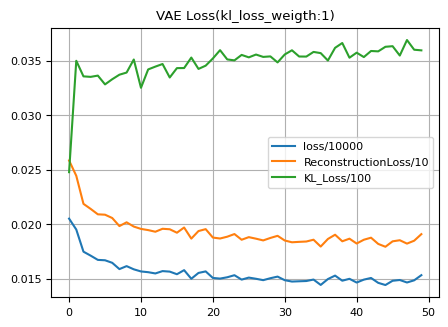

In [ ]:
v_num = logger.version
history = pd.read_csv(f'./logs/vae/version_{v_num}/metrics.csv')
df = history.groupby('epoch').last().drop('step', axis=1)

plt.title(f"VAE Loss(kl_loss_weigth:{kl_loss_weigth})")
plt.plot(df['loss']/10000,label='loss/10000')
plt.plot(df['recon_loss']/10,label='ReconstructionLoss/10')
plt.plot(df['kl_loss']/100,label='KL_Loss/100')
#plt.semilogy()
plt.legend()
plt.grid()

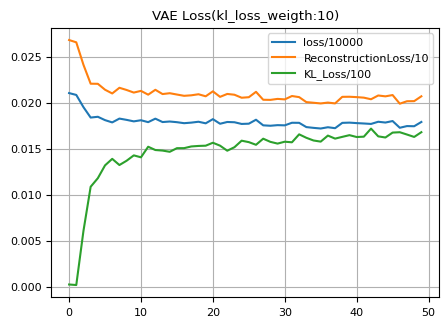

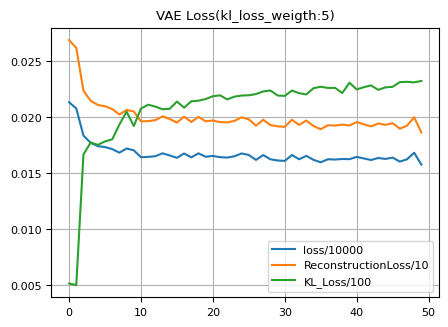

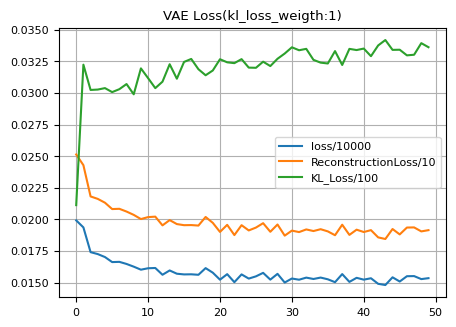

## VAE model instantiation, Compile, Fit

## **Analysis**

### Decoded image

In [ ]:
from scipy.stats import norm

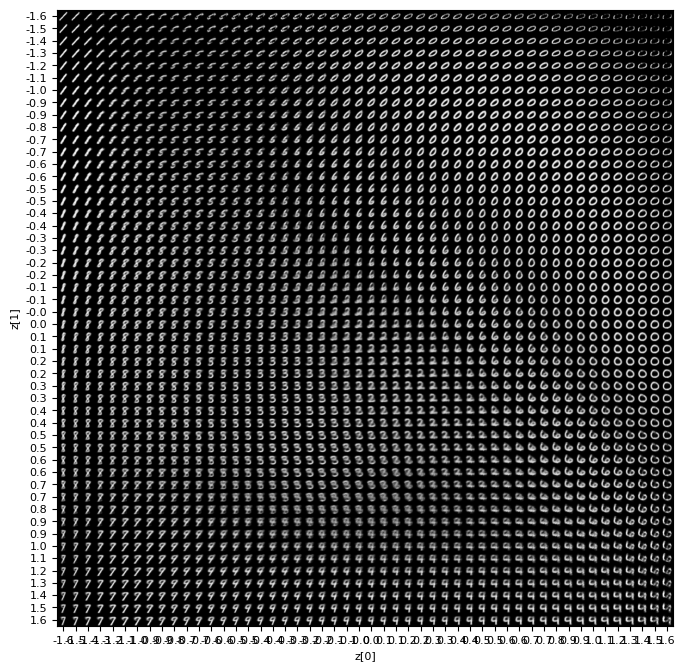

In [ ]:
batch_size = 1
n = 50
figsize = 8

figure = np.zeros((28 * n, 28 * n))
grid_x = norm.ppf(np.linspace(0.05, 0.95, n))
grid_y = norm.ppf(np.linspace(0.05, 0.95, n))
vae.eval()
with torch.no_grad():
  for i, xi in enumerate(grid_x):
    for j, yi in enumerate(grid_y):
      z_sample = np.array([[xi, yi]])

      # 그리드 좌표값으로 추론
      x_decoded = vae.decoder.to(device)(torch.Tensor(z_sample).to(device))
      x_decoded = x_decoded.cpu().detach().numpy()
      digit = x_decoded[0].reshape(28, 28)

      figure[i * 28: (i + 1) * 28,
            j * 28: (j + 1) * 28] = digit

plt.figure(figsize=(figsize, figsize))
start_range = 28 // 2
end_range = n * 28 + start_range # + 1
pixel_range = np.arange(start_range, end_range, 28)
sample_range_x = np.round(grid_x, 1)
sample_range_y = np.round(grid_y, 1)
plt.xticks(pixel_range, sample_range_x)
plt.yticks(pixel_range, sample_range_y)
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.imshow(figure, cmap="Greys_r")
plt.show()

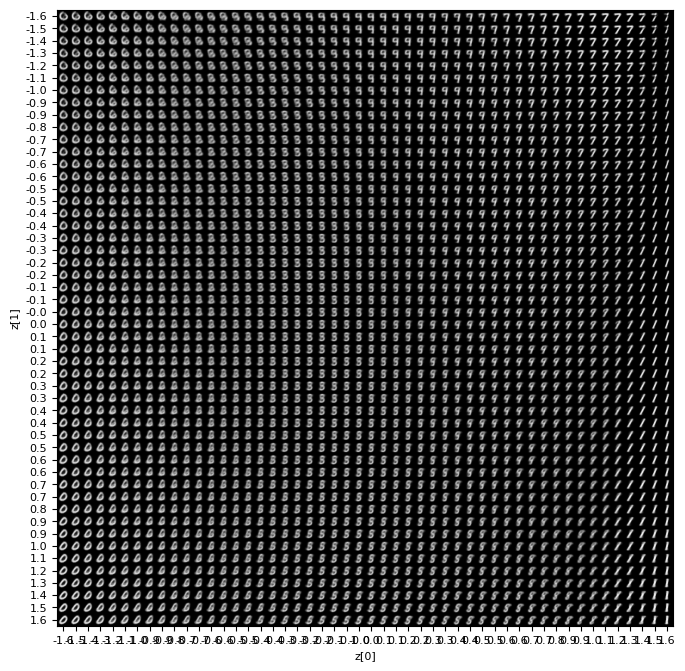

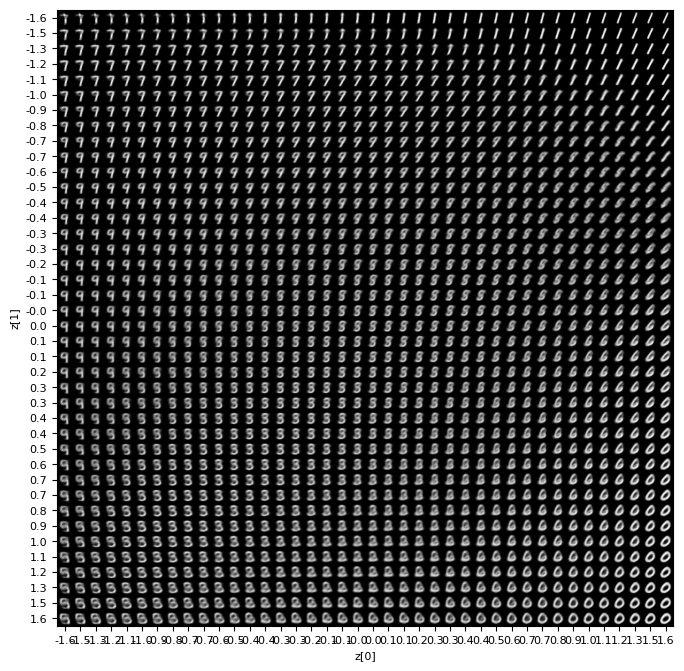

### ppf()
`grid_x = norm.ppf(np.linspace(0.05, 0.95, n))`
> pdf : 확률밀도함수
> cdf : 누적밀도함수
> ppf : 확률밀도함수 역함수

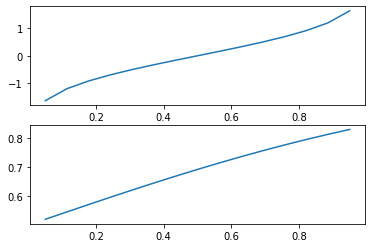

## 잠재영역의 군집화된 모습 시각화


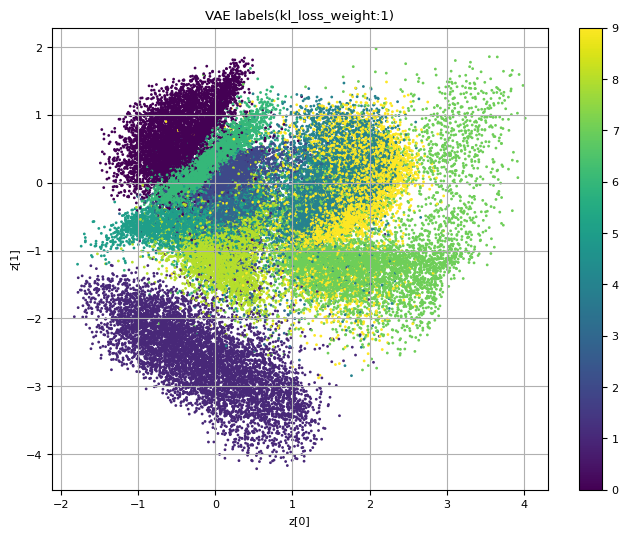

In [ ]:
def plot_label_clusters(encoder, trainDataloader):
# display a 2D plot of the digit classes in the latent space
#    z_mean, _, _ = encoder2.predict(data) # data.shape:(60000,28,28,1)
    z_means = []
    labels = []
    for data, label in trainDataloader:
        # (60000,(z0,z1)) <- (60000,1,28,28)
        z_mean, _, _ = encoder.to(device)(torch.Tensor(data).to(device))
        z_means.append(z_mean.cpu().detach().numpy())
        labels.append(label)
    z_means = np.concatenate(z_means)
    labels = np.concatenate(labels)
    # z_mean.shape:(60000,2)
    plt.figure(figsize=(8, 6))
    plt.title(f"VAE labels(kl_loss_weight:{kl_loss_weigth})")
    plt.scatter(z_means[:, 0], z_means[:, 1], c=labels,s=1) # z[0],z[1]
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.grid()
    plt.show()

trainDataloader = DataLoader(train_dataset, shuffle=False, batch_size=512)
plot_label_clusters(encoder, trainDataloader)

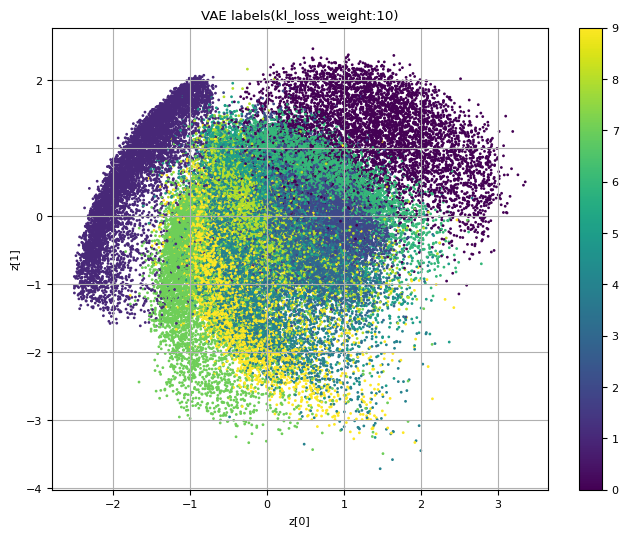

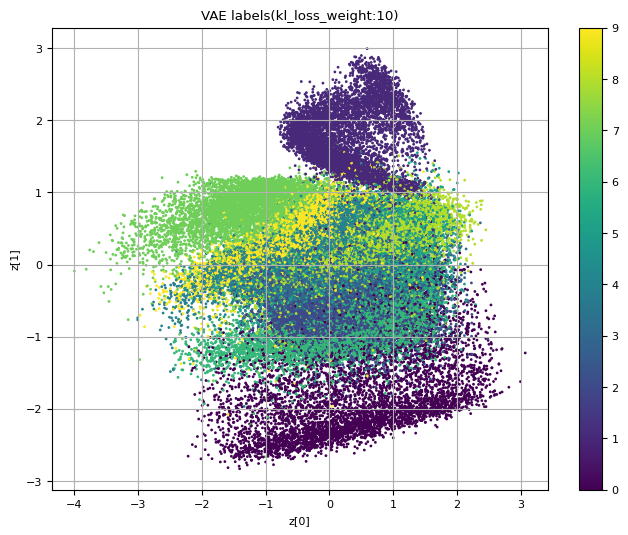

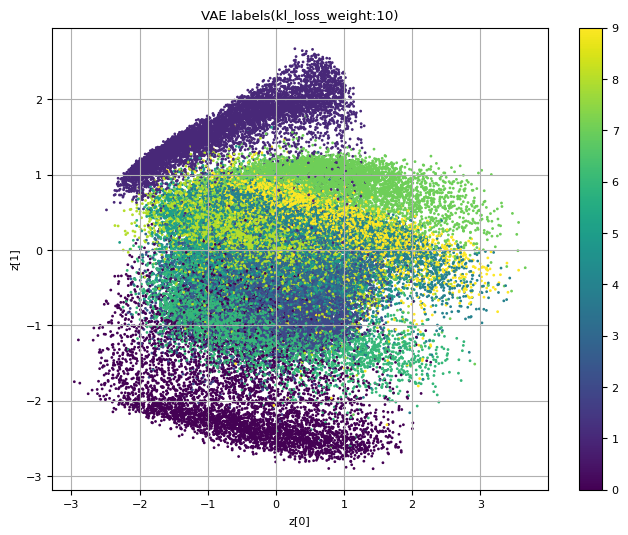

## z_mean vs. samped z   
### 4자가 어떻게 mapping되는지 시각화해 보자  

In [ ]:
def z_plot_label_clusters(encoder, trainDataloader):
# display a 2D plot of the digit classes in the latent space
#    z_mean, _, _ = encoder2.predict(data) # data.shape:(60000,28,28,1)
    z_means = []
    labels = []
    z_s = []
    for data, label in trainDataloader:
        if label != 4 : continue
        # (60000,(z0,z1)) <- (60000,1,28,28)
        for i in range(10):
            z_mean, z_log_var, z = encoder.to(device)(torch.Tensor(data).to(device))
            z_means.append(z_mean.cpu().detach().numpy())
            labels.append(label)
            z_s.append(z.cpu().detach().numpy())
    z_means = np.concatenate(z_means)
    labels = np.concatenate(labels)
    z_s = np.concatenate(z_s)

    plt.figure(figsize=(12, 6))
    plt.subplot(121)

    plt.title(f"z_means")
    plt.scatter(z_means[:, 0], z_means[:, 1], c=labels,s=1) # z[0],z[1]
    plt.ylim(-1,1)
    plt.xlim(-1,1)
    plt.grid()

    plt.subplot(122)
    plt.title(f"smapeled z")
    plt.scatter(z_s[:, 0], z_s[:, 1], c=labels, s=1) # z[0],z[1]
    plt.ylim(-1,1)
    plt.xlim(-1,1)
    plt.grid()
    plt.show()

trainDataloader = DataLoader(train_dataset, shuffle=False, batch_size=1)
z_plot_label_clusters(encoder, trainDataloader)

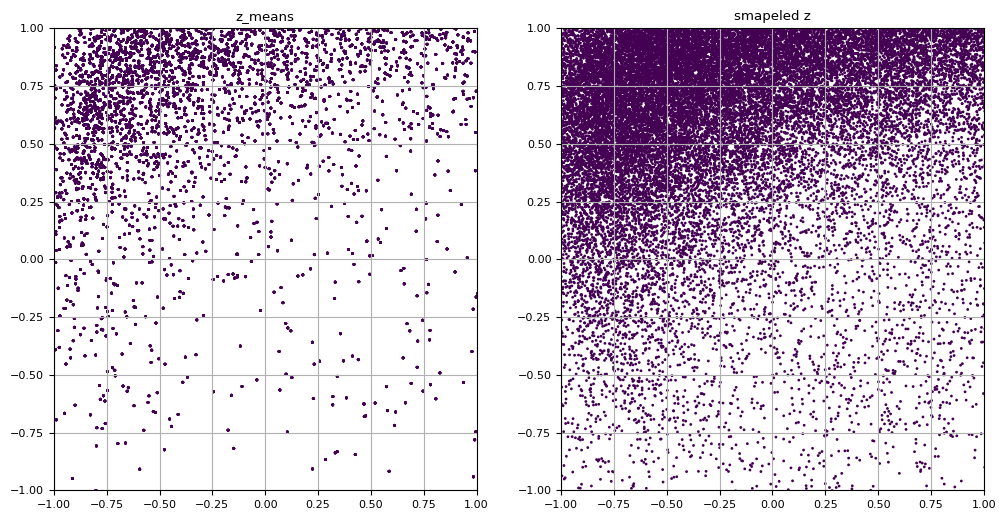